In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from hmmlearn import hmm
import numpy as np

In [2]:
df = pd.read_csv("../data/normalized-perchip-arcsinh.csv", index_col=0)

CDHMM over time, view the states
graph of the probability of each state of time, then maybe a sampling / simulation from the CDHMM

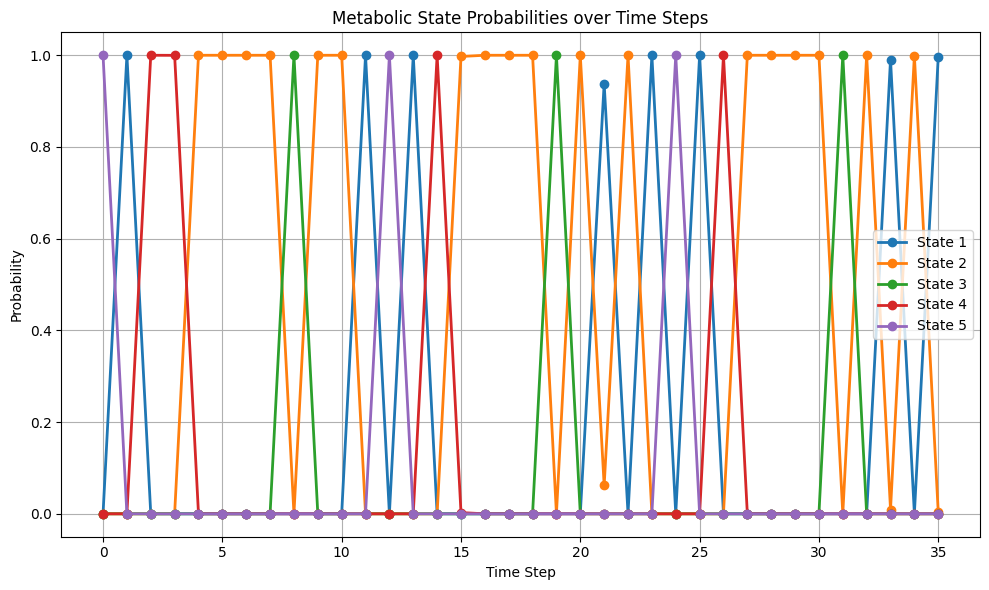

<Figure size 640x480 with 0 Axes>

In [9]:
# Drop the first column if it is just a time/index column
X = df.drop(columns=[df.columns[0]]).values 

# 2. Reduce dimensions using PCA
pca = PCA(n_components=7, random_state=42)
X_pca = pca.fit_transform(X)

# 3. Fit a Continuous Density HMM (Gaussian HMM)
n_states = 5
model = hmm.GaussianHMM(n_components=n_states, covariance_type="diag", n_iter=100, random_state=42)
model.fit(X_pca)

# 4. Predict the probability of each state over the time steps
state_probs = model.predict_proba(X_pca)

# 5. Plot the probabilities
plt.figure(figsize=(10, 6))
for i in range(n_states):
    plt.plot(state_probs[:, i], label=f'State {i+1}', lw=2, marker='o')

plt.title('Metabolic State Probabilities over Time Steps')
plt.xlabel('Time Step')
plt.ylabel('Probability')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig("CDHMM_states.png")

--- BIOLOGICAL MEANING OF STATES ---
State 1 is driven by high expression of: <StringArray>
['8020_s_at', '6082_at', '8142_s_at', '11356_at', '9309_at']
Length: 5, dtype: str
State 2 is driven by high expression of: <StringArray>
['6082_at', '8020_s_at', '11356_at', '8142_s_at', '9309_at']
Length: 5, dtype: str
State 3 is driven by high expression of: <StringArray>
['8808_at', '5005_at', '9198_s_at', '7927_at', '9947_i_at']
Length: 5, dtype: str
State 4 is driven by high expression of: <StringArray>
['9185_at', '7359_at', '8313_at', '9947_i_at', '9198_s_at']
Length: 5, dtype: str


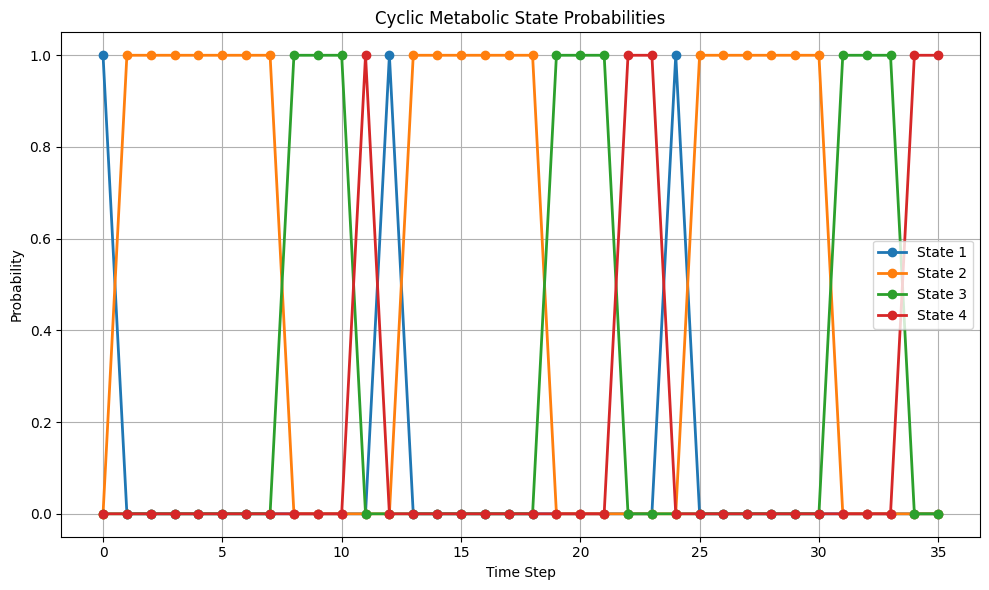

In [4]:
gene_names = df.columns[1:] # Keep track of actual gene names
X = df.drop(columns=[df.columns[0]]).values 

# 2. FEATURE SELECTION (Instead of PCA)
# Find the 100 most variable genes over time to avoid overfitting
variances = np.var(X, axis=0)
top_100_idx = np.argsort(variances)[-100:] # Get indices of top 100
X_top = X[:, top_100_idx]
top_gene_names = gene_names[top_100_idx]

# 3. FIT A CYCLIC HMM
n_states = 4 # 4 is usually better for yeast metabolic cycle (Oxidative, Reductive, etc.)

# Force a Left-to-Right Cyclic Transition Matrix
# e.g. State 1 goes to State 1 or 2. State 4 goes to State 4 or 1.
transmat = np.zeros((n_states, n_states))
for i in range(n_states):
    transmat[i, i] = 0.5                     # 50% chance to stay in current state
    transmat[i, (i + 1) % n_states] = 0.5    # 50% chance to move to NEXT state in the cycle

model = hmm.GaussianHMM(n_components=n_states, covariance_type="diag", init_params="mcs", random_state=42)
model.transmat_ = transmat # Apply our custom continuous cycle

# Fit the model on the filtered genes
model.fit(X_top)

# 4. Predict probabilities
state_probs = model.predict_proba(X_top)

# 5. UNDERSTAND THE STATES (Biological Extraction)
print("--- BIOLOGICAL MEANING OF STATES ---")
for i in range(n_states):
    # model.means_[i] contains the average expression of our 100 genes in State i
    # Let's find the top 5 most highly expressed genes in this state
    top_genes_for_state = np.argsort(model.means_[i])[-5:]
    print(f"State {i+1} is driven by high expression of: {top_gene_names[top_genes_for_state].values}")

# 6. Plot the continuous probabilities
plt.figure(figsize=(10, 6))
for i in range(n_states):
    plt.plot(state_probs[:, i], label=f'State {i+1}', lw=2, marker='o')

plt.title('Cyclic Metabolic State Probabilities')
plt.xlabel('Time Step')
plt.ylabel('Probability')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

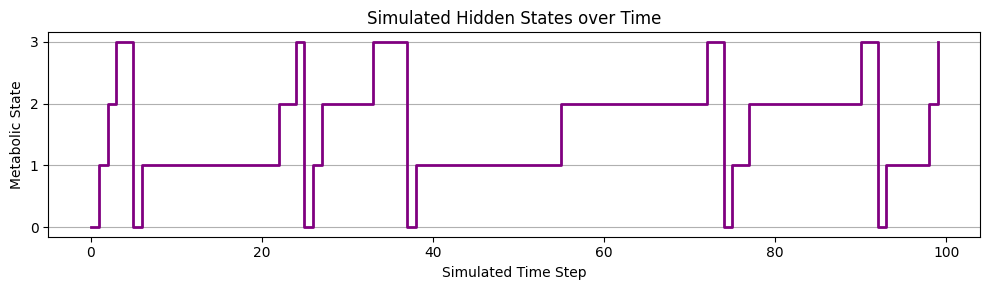

In [5]:
# 3. SIMULATE NEW DATA
n_samples_to_simulate = 100
# The .sample() method returns both the synthetic gene expression AND the hidden states!
simulated_expression, simulated_states = model.sample(n_samples_to_simulate)

# 4. Plot the simulated hidden states
plt.figure(figsize=(10, 3))
plt.step(range(n_samples_to_simulate), simulated_states, where='post', color='purple', lw=2)
plt.title('Simulated Hidden States over Time')
plt.xlabel('Simulated Time Step')
plt.ylabel('Metabolic State')
plt.yticks(range(n_states))
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()